In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_features.csv
/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_classes.csv
/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_edgelist.csv


# **PS2**

# **STEP 1 — Imports**

In [2]:

import os
import gc
import math
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

# **STEP 2 — Paths and settings**

In [4]:

BASE_PATH = "/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset"

FEATURES_PATH = os.path.join(BASE_PATH, "elliptic_txs_features.csv")
CLASSES_PATH  = os.path.join(BASE_PATH, "elliptic_txs_classes.csv")
EDGES_PATH    = os.path.join(BASE_PATH, "elliptic_txs_edgelist.csv")

BETWEENNESS_K = 10000
BETWEENNESS_SEED = 42

TOP_PCTS = [0.10, 0.05, 0.02, 0.01, 0.005]

TX_COL = "txId"
TIME_COL = "time_step"
RAW_CLASS_COL = "class"
CLASS_LABEL_COL = "class_label"

print("FEATURES_PATH:", FEATURES_PATH)
print("CLASSES_PATH :", CLASSES_PATH)
print("EDGES_PATH   :", EDGES_PATH)
print("BETWEENNESS_K:", BETWEENNESS_K)

FEATURES_PATH: /kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_features.csv
CLASSES_PATH : /kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_classes.csv
EDGES_PATH   : /kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_edgelist.csv
BETWEENNESS_K: 10000


# **STEP 3 - LOAD DATA**

In [5]:
# STEP 3 - LOAD DATA

features_df = pd.read_csv(FEATURES_PATH, header=None)
classes_df = pd.read_csv(CLASSES_PATH)
edges_df = pd.read_csv(EDGES_PATH)

print("features_df shape:", features_df.shape)
print("classes_df  shape:", classes_df.shape)
print("edges_df    shape:", edges_df.shape)

display(features_df.head())
display(classes_df.head())
display(edges_df.head())

features_df shape: (203769, 167)
classes_df  shape: (203769, 2)
edges_df    shape: (234355, 2)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,-0.167933,-0.049707,-0.164402,-0.028741,-0.035391,-0.042955,-0.013282,-0.057195,-0.169609,-0.171154,-0.174473,-1.373657,-1.371460,-0.139731,-0.148912,-0.080147,-0.155661,-0.010763,-0.012107,-0.139733,-0.148907,-0.080147,-0.155661,-0.010669,-0.012005,-0.024669,-0.031272,-0.023045,-0.026215,0.001428,0.001483,-0.227215,-0.239368,-0.075256,-0.234952,0.037468,0.043444,-0.227203,-0.243236,-0.097895,-0.235896,0.036577,0.042345,-0.414005,-0.488340,-0.232553,-0.467554,0.048767,0.052956,-0.039149,-0.172895,-0.163126,-0.160932,-1.316342,-1.315388,-0.039144,-0.172884,-0.163115,-0.160925,-1.316333,-1.315375,-0.017032,-0.030026,-0.017640,-0.015071,-0.140763,-0.140335,-0.095403,-0.264376,-0.250523,-0.263703,1.133527,1.135947,-0.059013,-0.262368,-0.255111,-0.259194,1.125590,1.128038,-0.293773,-0.159732,0.034039,-0.183816,1.135523,1.135279,-0.169160,-0.201584,-0.116817,-0.191472,-0.014659,-0.018849,-1.457953,-1.494057,-0.083459,-1.485972,-0.088798,-0.090437,-0.166550,-0.216536,-0.134546,-0.194817,-0.003175,-0.004094,-1.096336,-1.267340,-0.349933,-1.230441,-0.004358,-0.004194,-0.116425,-0.176617,-0.137323,-0.152464,-0.026060,-0.027660,-0.093145,-0.143707,-0.097719,-0.127462,0.003143,0.002426,-0.120950,-0.199145,-0.187993,-0.212948,1.064205,1.063787,-1.373782,-1.354735,-0.297975,-1.403698,1.342003,1.340733,-0.171601,-0.458162,-0.423588,-0.440883,-1.015963,-1.016230,-0.968903,-0.375715,0.759748,-0.768329,1.488113,1.487932,-0.216814,-0.605631,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,-0.167948,-0.049707,-0.164417,-0.028741,-0.035391,-0.042955,-0.013282,-0.055327,-0.169757,-0.171477,-0.174490,0.887058,0.884557,-0.139731,-0.148912,-0.080147,-0.155661,-0.010763,-0.012107,-0.139733,-0.148907,-0.080147,-0.155661,-0.010669,-0.012005,-0.024669,-0.031272,-0.023045,-0.026215,0.001428,0.001483,-0.227215,-0.239368,-0.075256,-0.234952,0.037468,0.043444,-0.227203,-0.243236,-0.097895,-0.235896,0.036577,0.042345,-0.413965,-0.488307,-0.232553,-0.467516,0.048767,0.052956,-0.039151,-0.172895,-0.163126,-0.160933,0.923473,0.923011,-0.039146,-0.172884,-0.163114,-0.160926,0.923516,0.923110,-0.017032,-0.030026,-0.017640,-0.015071,-0.140763,-0.140335,-0.095403,-0.264425,-0.250574,-0.263753,-0.169119,-0.167165,-0.059013,-0.262424,-0.255168,-0.259251,-0.187191,-0.185274,-0.293692,-0.760700,-0.692777,-0.719789,-1.084907,-1.084845,-0.170113,-0.202332,-0.116817,-0.192405,-0.014659,-0.018849,-1.457921,-1.494024,-0.083459,-1.485939,-0.088798,-0.090437,-0.166550,-0.216536,-0.134546,-0.194817,-0.003175,-0.004094,-1.096336,-1.267340,-0.349933,-1.230441,-0.004358,-0.004194,-0.116425,-0.176617,-0.137323,-0.152464,-0.026060,-0.027660,-0.093145,-0.143707,-0.097719,-0.127462,0.003143,0.002426,-0.121330,-0.110933,-0.075909,-0.111641,-1.159649,-1.160129,-1.373723,-1.353918,-0.295982,-1.403215,-0.975738,-0.975237,-0.168742,-0.263290,-0.186389,-0.250875,-1.015963,-1.016230,-0.968903,0.146997,1.366287,-0.464773,-1.116918,-1.116948,-0.216814,0.634272,0.947382,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,-0.168576,-0.049707,-0.165054,-0.028741,-0.035391,-0.042955,-0.013282,

,txId,class
0,230425980,unknown
1,5530458,unknown
2,232022460,unknown
3,232438397,2
4,230460314,unknown


,txId1,txId2
0,230425980,5530458
1,232022460,232438397
2,230460314,230459870
3,230333930,230595899
4,232013274,232029206


In [6]:
assert features_df.shape[0] == 203769, f"Expected 203769 nodes, got {features_df.shape[0]}"
assert edges_df.shape[0] == 234355, f"Expected 234355 edges, got {edges_df.shape[0]}"
assert set(classes_df["class"].astype(str).unique()).issubset({"1", "2", "unknown"})
assert classes_df["txId"].nunique() == len(classes_df), "Duplicate txIds"
print("✓ All sanity assertions passed.")

✓ All sanity assertions passed.


# STEP 4 - PREPARE NODE TABLE

In [7]:
# STEP 4 - PREPARE NODE TABLE

n_cols = features_df.shape[1]
col_names = [TX_COL, TIME_COL] + [f"feature_{i}" for i in range(2, n_cols)]
features_df.columns = col_names

node_df = features_df[[TX_COL, TIME_COL]].copy()

print("node_df shape:", node_df.shape)
display(node_df.head())

node_df shape: (203769, 2)


,txId,time_step
0,230425980,1
1,5530458,1
2,232022460,1
3,232438397,1
4,230460314,1


# STEP 5 - PREPARE LABEL TABLE

In [8]:
# STEP 5 - PREPARE LABEL TABLE

classes_df[RAW_CLASS_COL] = classes_df[RAW_CLASS_COL].astype(str)

class_map = {
    "1": "illicit",
    "2": "licit",
    "unknown": "unknown"
}

classes_df[CLASS_LABEL_COL] = classes_df[RAW_CLASS_COL].map(class_map)

print(classes_df[CLASS_LABEL_COL].value_counts(dropna=False))
display(classes_df.head())

class_label
unknown    157205
licit       42019
illicit      4545
Name: count, dtype: int64


,txId,class,class_label
0,230425980,unknown,unknown
1,5530458,unknown,unknown
2,232022460,unknown,unknown
3,232438397,2,licit
4,230460314,unknown,unknown


# STEP 6 - BUILD THE BASE DATAFRAME


In [9]:
# STEP 6 - BUILD THE BASE DATAFRAME

base_df = node_df.merge(
    classes_df[[TX_COL, RAW_CLASS_COL, CLASS_LABEL_COL]],
    on=TX_COL,
    how="left"
)

print("base_df shape:", base_df.shape)
display(base_df.head())

print("\nClass distribution:")
print(base_df[CLASS_LABEL_COL].value_counts(dropna=False))

base_df shape: (203769, 4)


,txId,time_step,class,class_label
0,230425980,1,unknown,unknown
1,5530458,1,unknown,unknown
2,232022460,1,unknown,unknown
3,232438397,1,2,licit
4,230460314,1,unknown,unknown



Class distribution:
class_label
unknown    157205
licit       42019
illicit      4545
Name: count, dtype: int64


# STEP 7 - BUILD THE DIRECTED GRAPH

In [10]:
# STEP 7 - BUILD THE DIRECTED GRAPH

G = nx.DiGraph()

G.add_nodes_from(base_df[TX_COL].tolist())

print("edges_df columns:", edges_df.columns.tolist())

source_col = edges_df.columns[0]
target_col = edges_df.columns[1]

edge_tuples = list(edges_df[[source_col, target_col]].itertuples(index=False, name=None))
G.add_edges_from(edge_tuples)

print("Graph built.")
print("Number of nodes:", f"{G.number_of_nodes():,}")
print("Number of edges:", f"{G.number_of_edges():,}")
print("Is DAG?:", nx.is_directed_acyclic_graph(G))
print("Weakly connected components:", nx.number_weakly_connected_components(G))

edges_df columns: ['txId1', 'txId2']
Graph built.
Number of nodes: 203,769
Number of edges: 234,355
Is DAG?: True
Weakly connected components: 49


# STEP 8 - COMPUTE APPROXIMATE BETWEENNESS

In [11]:
# STEP 8 - COMPUTE APPROXIMATE BETWEENNESS

betweenness_dict = nx.betweenness_centrality(
    G,
    k=min(BETWEENNESS_K, G.number_of_nodes()),
    normalized=True,
    seed=BETWEENNESS_SEED
)

betweenness_df = pd.DataFrame({
    TX_COL: list(betweenness_dict.keys()),
    "betweenness": list(betweenness_dict.values())
})

print("betweenness_df shape:", betweenness_df.shape)
display(betweenness_df.head())
display(betweenness_df["betweenness"].describe())

betweenness_df shape: (203769, 2)


,txId,betweenness
0,230425980,9.815132e-10
1,5530458,4.907566e-10
2,232022460,0.000000e+00
3,232438397,3.926053e-08
4,230460314,0.000000e+00


count    2.037690e+05
mean     8.552862e-08
std      5.974819e-07
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      8.943058e-06
Name: betweenness, dtype: float64

# STEP 8B - TÌM K STABLE CHO BETWEENNESS

Test-Retest Reliability — đo xem một công cụ đo lường có cho ra kết quả nhất quán khi lặp lại trong cùng điều kiện không.

Trong trường hợp của bạn:

- "Công cụ" = RA-Brandes approximation với k source nodes
- "Lặp lại" = chạy 3 lần với seed khác nhau (42, 7, 123)
- "Nhất quán" = Pearson correlation giữa các lần chạy > 0.95

In [ ]:
# STEP 8B - TÌM K STABLE CHO BETWEENNESS

import time

for k_test in [5000, 10000, 20000]:
    results = []
    t0 = time.time()
    
    for seed in [42, 7, 123]:
        bet = nx.betweenness_centrality(G, k=k_test, normalized=True, seed=seed)
        bet_df = pd.DataFrame({
            TX_COL: list(bet.keys()),
            f"bet_seed{seed}": list(bet.values())
        })
        results.append(bet_df)
    
    elapsed = time.time() - t0
    
    # Merge 3 seeds
    stab_df = results[0]
    for r in results[1:]:
        stab_df = stab_df.merge(r, on=TX_COL)
    
    corr = stab_df[[f"bet_seed42", f"bet_seed7", f"bet_seed123"]].corr()
    min_corr = corr.min().min()
    
    print(f"k={k_test:>6} | min_corr={min_corr:.4f} | time={elapsed:.0f}s", end="  ")
    
    if min_corr > 0.95:
        print("✓ STABLE — dùng k này")
        BETWEENNESS_K = k_test  # cập nhật luôn
        break
    else:
        print("✗ unstable, thử k lớn hơn")

k=  5000 | min_corr=0.9395 | time=6102s  ✗ unstable, thử k lớn hơn


# STEP 8C — MEDIAN BETWEENNESS QUA 3 SEEDS (thay thế Step 8 gốc)

In [ ]:
# STEP 8C — MEDIAN BETWEENNESS QUA 3 SEEDS (thay thế Step 8 gốc)
# Plan §3.3: report enrichment as median over 3 seeds with min-max range

seeds_final = [42, 7, 123]
bc_runs = []

print(f"Computing median betweenness with k={BETWEENNESS_K}, seeds={seeds_final}...")

for _seed in seeds_final:
    _b = nx.betweenness_centrality(G, k=BETWEENNESS_K, normalized=True, seed=_seed)
    bc_runs.append(pd.DataFrame({
        TX_COL: list(_b.keys()),
        f"bet_seed{_seed}": list(_b.values())
    }))
    print(f"  seed={_seed} done.")

bc_merged = bc_runs[0]
for r in bc_runs[1:]:
    bc_merged = bc_merged.merge(r, on=TX_COL)

seed_cols = [f"bet_seed{s}" for s in seeds_final]
bc_merged["betweenness"]  = bc_merged[seed_cols].median(axis=1)
bc_merged["bet_range"]    = bc_merged[seed_cols].max(axis=1) - bc_merged[seed_cols].min(axis=1)

# Stability check
med_range = bc_merged["bet_range"].median()
med_bet   = bc_merged["betweenness"].replace(0, np.nan).median()
stability_ratio = med_range / (med_bet + 1e-12)

print(f"\nApproximation stability:")
print(f"  median betweenness : {med_bet:.8f}")
print(f"  median seed range  : {med_range:.8f}")
print(f"  range/median ratio : {stability_ratio:.4f}")
if stability_ratio > 0.5:
    print("  ⚠ UNSTABLE — mark as 'unstable approximation' in results table")
else:
    print("  ✓ STABLE — median over 3 seeds is reliable")

# Ghi đè betweenness_df để các step sau dùng median thay vì 1-seed
betweenness_df = bc_merged[[TX_COL, "betweenness", "bet_range"]].copy()

print("\nbetweenness_df shape:", betweenness_df.shape)
display(betweenness_df.head())
display(betweenness_df["betweenness"].describe())

In [12]:
# Save để không phải tính lại
betweenness_df.to_csv("/kaggle/working/ps2_betweenness_3seeds.csv", index=False)
print("Saved betweenness to CSV.")

Saved betweenness to CSV.


# Những lần chạy sau, skip Step 8, 8B, 8C và thay bằng cell load:

# STEP 8 FAST LOAD — dùng kết quả đã tính sẵn
betweenness_df = pd.read_csv("/kaggle/working/ps2_betweenness_3seeds.csv")
print("Loaded betweenness from cache. Shape:", betweenness_df.shape)
display(betweenness_df.head())

In [14]:
betweenness_df = pd.read_csv("/kaggle/working/ps2_betweenness_3seeds.csv")
print("Loaded betweenness from cache. Shape:", betweenness_df.shape)
display(betweenness_df.head())

Loaded betweenness from cache. Shape: (203769, 2)


,txId,betweenness
0,230425980,9.815132e-10
1,5530458,4.907566e-10
2,232022460,0.000000e+00
3,232438397,3.926053e-08
4,230460314,0.000000e+00


# STEP 9 - COMPUTE HARMONIC CLOSENESS

In [15]:
# STEP 9 - COMPUTE HARMONIC CLOSENESS

harmonic_dict = nx.harmonic_centrality(G)

harmonic_df = pd.DataFrame({
    TX_COL: list(harmonic_dict.keys()),
    "harmonic_closeness": list(harmonic_dict.values())
})

print("harmonic_df shape:", harmonic_df.shape)
display(harmonic_df.head())
display(harmonic_df["harmonic_closeness"].describe())

harmonic_df shape: (203769, 2)


,txId,harmonic_closeness
0,272105479,0.000000
1,395313180,2.083333
2,339738664,3.961654
3,4718635,1.000000
4,48234540,0.000000


count    203769.000000
mean          3.192921
std           9.641385
min           0.000000
25%           0.000000
50%           1.500000
75%           3.439553
max         609.277058
Name: harmonic_closeness, dtype: float64

# STEP 10 - MERGE PS2 METRICS

In [16]:
# STEP 10 - MERGE PS2 METRICS

ps2_metrics_df = betweenness_df.merge(harmonic_df, on=TX_COL, how="inner")

ps2_df = base_df.merge(ps2_metrics_df, on=TX_COL, how="left")

print("ps2_metrics_df shape:", ps2_metrics_df.shape)
print("ps2_df shape:", ps2_df.shape)

display(ps2_df.head())

ps2_metrics_df shape: (203769, 3)
ps2_df shape: (203769, 6)


,txId,time_step,class,class_label,betweenness,harmonic_closeness
0,230425980,1,unknown,unknown,9.815132e-10,2.592857
1,5530458,1,unknown,unknown,4.907566e-10,2.717857
2,232022460,1,unknown,unknown,0.000000e+00,1.833333
3,232438397,1,2,licit,3.926053e-08,271.798424
4,230460314,1,unknown,unknown,0.000000e+00,2.500000


# standardize Harmonic

In [17]:
# standardize Harmonic
n = G.number_of_nodes()
ps2_df["harmonic_closeness_norm"] = ps2_df["harmonic_closeness"] / (n - 1)

# STEP 11 - ADD DEGREE METRICS

In [18]:
# STEP 11 - ADD DEGREE METRICS

in_deg_dict = dict(G.in_degree())
out_deg_dict = dict(G.out_degree())

degree_df = pd.DataFrame({
    TX_COL: list(G.nodes()),
    "in_degree": [in_deg_dict[n] for n in G.nodes()],
    "out_degree": [out_deg_dict[n] for n in G.nodes()]
})

degree_df["total_degree"] = degree_df["in_degree"] + degree_df["out_degree"]

ps2_df = ps2_df.merge(degree_df, on=TX_COL, how="left")

print("ps2_df shape after degree merge:", ps2_df.shape)
display(ps2_df.head())

ps2_df shape after degree merge: (203769, 10)


,txId,time_step,class,class_label,betweenness,harmonic_closeness,harmonic_closeness_norm,in_degree,out_degree,total_degree
0,230425980,1,unknown,unknown,9.815132e-10,2.592857,0.000013,1,1,2
1,5530458,1,unknown,unknown,4.907566e-10,2.717857,0.000013,1,1,2
2,232022460,1,unknown,unknown,0.000000e+00,1.833333,0.000009,1,2,3
3,232438397,1,2,licit,3.926053e-08,271.798424,0.001334,160,1,161
4,230460314,1,unknown,unknown,0.000000e+00,2.500000,0.000012,2,8,10


# STEP 11B — BOTTLENECK RATIO

In [19]:
# STEP 11B — BOTTLENECK RATIO
# Plan §5.2: separates exchanges (high BC + high degree) from
# laundering intermediaries (high BC + moderate degree)
# Formula: bottleneck_ratio(v) = BC(v) / (degree(v) × mean_neighbour_degree(v))

print("Computing mean neighbour degree...")

mean_neighbour_deg = {}
for n in G.nodes():
    neighbours = list(G.predecessors(n)) + list(G.successors(n))
    if len(neighbours) == 0:
        mean_neighbour_deg[n] = 0.0
    else:
        mean_neighbour_deg[n] = np.mean([
            in_deg_dict.get(nb, 0) + out_deg_dict.get(nb, 0)
            for nb in neighbours
        ])

ps2_df["mean_neighbour_degree"] = ps2_df[TX_COL].map(mean_neighbour_deg)

ps2_df["bottleneck_ratio"] = ps2_df["betweenness"] / (
    (ps2_df["total_degree"] * ps2_df["mean_neighbour_degree"]) + 1e-12
)

print("bottleneck_ratio stats:")
display(ps2_df["bottleneck_ratio"].describe())

Computing mean neighbour degree...
bottleneck_ratio stats:


count    2.037690e+05
mean     1.754384e-08
std      1.347142e-07
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      2.235764e-06
Name: bottleneck_ratio, dtype: float64

# STEP 11C — LABEL-COVERAGE DIAGNOSTIC FOR BOTTLENECK RATIO

In [20]:
# STEP 11C — LABEL-COVERAGE DIAGNOSTIC FOR BOTTLENECK RATIO
# Bắt buộc trước khi report enrichment — Plan §3.1

coverage_bottleneck = []

for pct in [0.005, 0.01, 0.02, 0.05, 0.10, 0.20]:
    cutoff = ps2_df["bottleneck_ratio"].quantile(1 - pct)
    subset = ps2_df[ps2_df["bottleneck_ratio"] >= cutoff]
    n_total   = len(subset)
    n_labelled = subset[CLASS_LABEL_COL].isin(["licit", "illicit"]).sum()
    pct_labelled = n_labelled / n_total * 100 if n_total > 0 else np.nan

    coverage_bottleneck.append({
        "bucket"       : f"Top {pct*100:.1f}%",
        "cutoff"       : cutoff,
        "n_total"      : n_total,
        "n_labelled"   : n_labelled,
        "pct_labelled" : round(pct_labelled, 2),
        "action"       : "OK — USABLE" if (n_labelled >= 30 and pct_labelled >= 5)
                         else "INSUFFICIENT LABEL COVERAGE"
    })

coverage_bottleneck_df = pd.DataFrame(coverage_bottleneck)
display(coverage_bottleneck_df)

,bucket,cutoff,n_total,n_labelled,pct_labelled,action
0,Top 0.5%,9.667463e-07,1019,0,0.00,INSUFFICIENT LABEL COVERAGE
1,Top 1.0%,5.967862e-07,2038,0,0.00,INSUFFICIENT LABEL COVERAGE
2,Top 2.0%,1.411918e-07,4076,0,0.00,INSUFFICIENT LABEL COVERAGE
3,Top 5.0%,2.420521e-08,10189,134,1.32,INSUFFICIENT LABEL COVERAGE
4,Top 10.0%,3.680674e-09,20548,919,4.47,INSUFFICIENT LABEL COVERAGE
5,Top 20.0%,5.074045e-11,40754,4911,12.05,OK — USABLE


# STEP 12 - GLOBAL PS2 STATISTICS

In [22]:
# STEP 12 - GLOBAL PS2 STATISTICS

global_ps2_stats = ps2_df[["betweenness", "harmonic_closeness_norm"]].describe().T
global_ps2_stats["non_zero_fraction"] = [
    (ps2_df["betweenness"] > 0).mean(),
    (ps2_df["harmonic_closeness"] > 0).mean()
]

display(global_ps2_stats)

print("Non-zero betweenness fraction:", round((ps2_df["betweenness"] > 0).mean(), 6))
print("Non-zero harmonic closeness fraction:", round((ps2_df["harmonic_closeness"] > 0).mean(), 6))

,count,mean,std,min,25%,50%,75%,max,non_zero_fraction
betweenness,203769.0,8.552862e-08,5.974819e-07,0.0,0.0,0.000000,0.000000,0.000009,0.214503
harmonic_closeness_norm,203769.0,1.566939e-05,4.731550e-05,0.0,0.0,0.000007,0.000017,0.002990,0.728506


Non-zero betweenness fraction: 0.214503
Non-zero harmonic closeness fraction: 0.728506


# STEP 13 - GROUP STATISTICS BY CLASS

In [23]:
# STEP 13 - GROUP STATISTICS BY CLASS

ps2_group_stats = (
    ps2_df
    .groupby(CLASS_LABEL_COL)[["betweenness", "harmonic_closeness_norm"]]
    .agg(["count", "mean", "median", "std"])
)

display(ps2_group_stats)

median_summary = (
    ps2_df
    .groupby(CLASS_LABEL_COL)[["betweenness", "harmonic_closeness_norm"]]
    .median()
    .sort_values("betweenness", ascending=False)
)

display(median_summary)

betweenness                                     \
                  count          mean median           std   
class_label                                                  
illicit            4545  4.934737e-09    0.0  2.504560e-08   
licit             42019  2.174775e-09    0.0  1.710973e-08   
unknown          157205  1.101382e-07    0.0  6.782160e-07   

            harmonic_closeness_norm                                
                              count      mean    median       std  
class_label                                                        
illicit                        4545  0.000011  0.000005  0.000045  
licit                         42019  0.000021  0.000007  0.000078  
unknown                      157205  0.000014  0.000009  0.000035

,betweenness,harmonic_closeness_norm
class_label,,
illicit,0.0,0.000005
licit,0.0,0.000007
unknown,0.0,0.000009


# STEP 14 - DEFINE ENRICHMENT FUNCTION

In [24]:
# STEP 14 - DEFINE ENRICHMENT FUNCTION

def enrichment_ratio(
    df_subset,
    class_col=CLASS_LABEL_COL,
    positive_label="illicit",
    baseline=0.0
):
    labeled_subset = df_subset[df_subset[class_col].isin(["licit", "illicit"])].copy()

    if len(labeled_subset) == 0:
        return {
            "n_subset_labeled": 0,
            "actual_illicit_count": 0,
            "expected_illicit_count": np.nan,
            "illicit_rate_subset": np.nan,
            "baseline_illicit_rate": baseline,
            "enrichment_ratio": np.nan,
            "lift_count": np.nan
        }

    actual_illicit_count = (labeled_subset[class_col] == positive_label).sum()
    illicit_rate_subset = actual_illicit_count / len(labeled_subset)
    expected_illicit_count = baseline * len(labeled_subset) if baseline > 0 else np.nan
    enrichment = illicit_rate_subset / baseline if baseline > 0 else np.nan
    lift_count = actual_illicit_count - expected_illicit_count if baseline > 0 else np.nan

    return {
        "n_subset_labeled": len(labeled_subset),
        "actual_illicit_count": actual_illicit_count,
        "expected_illicit_count": expected_illicit_count,
        "illicit_rate_subset": illicit_rate_subset,
        "baseline_illicit_rate": baseline,
        "enrichment_ratio": enrichment,
        "lift_count": lift_count
    }

# STEP 15 - COMPUTE BASELINE ILLICIT RATE

In [25]:
# STEP 15 - COMPUTE BASELINE ILLICIT RATE

labeled_all = ps2_df[ps2_df[CLASS_LABEL_COL].isin(["licit", "illicit"])].copy()
baseline_illicit = (labeled_all[CLASS_LABEL_COL] == "illicit").mean()

print("Baseline illicit rate:", round(baseline_illicit, 6))
print("Labeled nodes:", len(labeled_all))
print("Illicit count:", (labeled_all[CLASS_LABEL_COL] == "illicit").sum())
print("Licit count:", (labeled_all[CLASS_LABEL_COL] == "licit").sum())

Baseline illicit rate: 0.097608
Labeled nodes: 46564
Illicit count: 4545
Licit count: 42019


# STEP 16 - DEFINE THRESHOLD-SCAN FUNCTION

In [26]:
# STEP 16 - DEFINE THRESHOLD-SCAN FUNCTION

def scan_metric_thresholds(
    df,
    metric_col,
    thresholds,
    direction="ge",
    class_col=CLASS_LABEL_COL,
    positive_label="illicit",
    baseline=0.0
):
    results = []

    for t in thresholds:
        if direction == "ge":
            subset = df[df[metric_col] >= t].copy()
            rule = f"{metric_col} >= {t:.6f}"
        elif direction == "le":
            subset = df[df[metric_col] <= t].copy()
            rule = f"{metric_col} <= {t:.6f}"
        else:
            raise ValueError("direction must be 'ge' or 'le'")

        stats = enrichment_ratio(
            subset,
            class_col=class_col,
            positive_label=positive_label,
            baseline=baseline
        )

        stats["threshold"] = t
        stats["rule"] = rule
        stats["direction"] = direction
        stats["metric"] = metric_col
        stats["n_subset_total"] = len(subset)
        results.append(stats)

    return pd.DataFrame(results)

# LABEL-COVERAGE DIAGNOSTIC FOR HARMONIC CLOSENESS

In [27]:
# STEP 16B - LABEL-COVERAGE DIAGNOSTIC FOR HARMONIC CLOSENESS

coverage_harm = []

for pct in [0.005, 0.01, 0.02, 0.05, 0.10, 0.20, 0.30, 0.50]:
    cutoff = ps2_df["harmonic_closeness"].quantile(1 - pct)
    subset = ps2_df[ps2_df["harmonic_closeness"] >= cutoff]
    n_total = len(subset)
    n_labeled = subset[CLASS_LABEL_COL].isin(["licit", "illicit"]).sum()
    pct_labeled = n_labeled / n_total * 100 if n_total > 0 else 0

    coverage_harm.append({
        "top_%": f"Top {pct*100:.1f}%",
        "n_total": n_total,
        "n_labeled": n_labeled,
        "pct_labeled": round(pct_labeled, 2),
        "action": "OK" if n_labeled >= 30 else "INSUFFICIENT DATA"
    })

display(pd.DataFrame(coverage_harm))

,top_%,n_total,n_labeled,pct_labeled,action
0,Top 0.5%,1019,521,51.13,OK
1,Top 1.0%,2038,888,43.57,OK
2,Top 2.0%,4076,1691,41.49,OK
3,Top 5.0%,10189,3989,39.15,OK
4,Top 10.0%,20383,5487,26.92,OK
5,Top 20.0%,40767,8540,20.95,OK
6,Top 30.0%,61554,12309,20.00,OK
7,Top 50.0%,117552,23370,19.88,OK


# STEP 17 - SCAN HIGH HARMONIC THRESHOLDS

In [28]:

# STEP 17 - SCAN HIGH HARMONIC THRESHOLDS

harmonic_nonnull = ps2_df["harmonic_closeness_norm"].dropna()

harmonic_thresholds_high = sorted(
    harmonic_nonnull.quantile([0.50, 0.60, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 0.97, 0.99]).unique()
)

harmonic_scan_high_df = scan_metric_thresholds(
    ps2_df,
    metric_col="harmonic_closeness_norm",
    thresholds=harmonic_thresholds_high,
    direction="ge",
    class_col=CLASS_LABEL_COL,
    positive_label="illicit",
    baseline=baseline_illicit
)

display(harmonic_scan_high_df.sort_values("threshold"))

,n_subset_labeled,actual_illicit_count,expected_illicit_count,illicit_rate_subset,baseline_illicit_rate,enrichment_ratio,lift_count,threshold,rule,direction,metric,n_subset_total
0,23370,2214,2281.089468,0.094737,0.097608,0.970589,-67.089468,0.000007,harmonic_closeness_norm >= 0.000007,ge,harmonic_closeness_norm,117552
1,15958,1023,1557.621983,0.064106,0.097608,0.656770,-534.621983,0.000010,harmonic_closeness_norm >= 0.000010,ge,harmonic_closeness_norm,82107
2,12309,658,1201.451873,0.053457,0.097608,0.547671,-543.451873,0.000014,harmonic_closeness_norm >= 0.000014,ge,harmonic_closeness_norm,61554
3,10259,550,1001.356305,0.053611,0.097608,0.549255,-451.356305,0.000017,harmonic_closeness_norm >= 0.000017,ge,harmonic_closeness_norm,50990
4,8540,457,833.568851,0.053513,0.097608,0.548245,-376.568851,0.000019,harmonic_closeness_norm >= 0.000019,ge,harmonic_closeness_norm,40767
5,6884,356,671.930676,0.051714,0.097608,0.529817,-315.930676,0.000022,harmonic_closeness_norm >= 0.000022,ge,harmonic_closeness_norm,30581
6,5487,184,535.572867,0.033534,0.097608,0.343557,-351.572867,0.000027,harmonic_closeness_norm >= 0.000027,ge,harmonic_closeness_norm,20383
7,3989,105,389.356692,0.026322,0.097608,0.269676,-284.356692,0.000038,harmonic_closeness_norm >= 0.000038,ge,harmonic_closeness_norm,10189
8,2465,61,240.602719,0.024746,0.097608,0.253530,-179.602719,0.000064,harmonic_closeness_norm >= 0.000064,ge,harmonic_closeness_norm,6125
9,888,30,86.675543,0.033784,0.097608,0.346118,-56.675543,0.000170,harmonic_closeness_norm >= 0.000170,ge,harmonic_closeness_norm,2038


# STEP 18 - PLOT HIGH HARMONIC SCAN

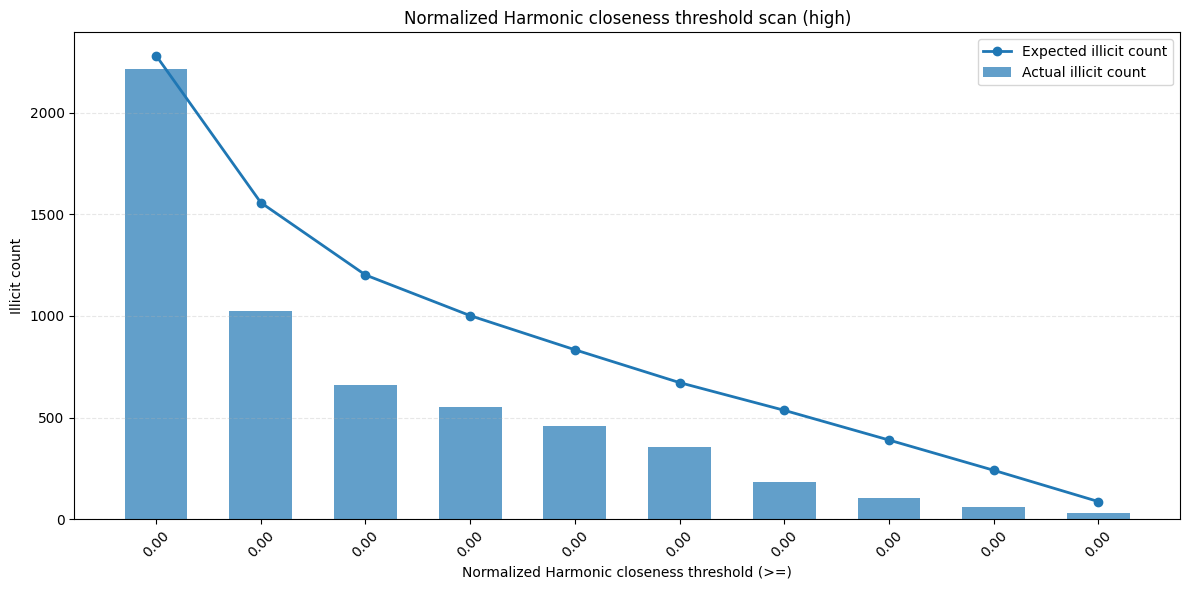

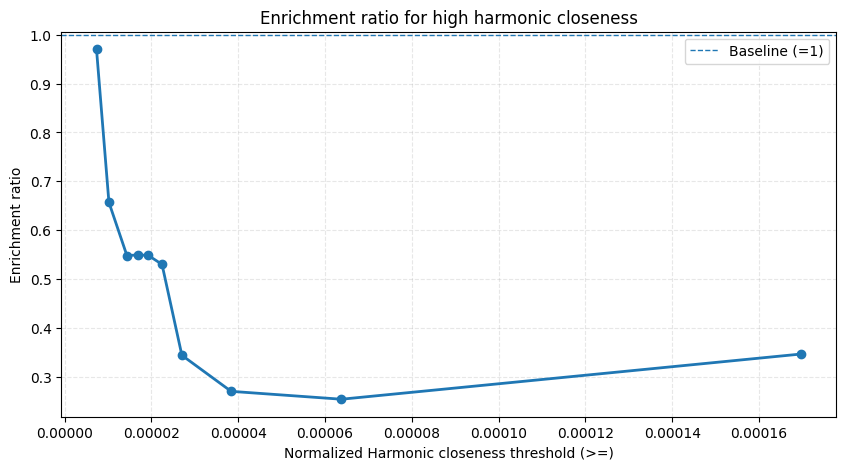

In [29]:
# STEP 18 - PLOT HIGH HARMONIC SCAN

fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(harmonic_scan_high_df))

ax.bar(
    x,
    harmonic_scan_high_df["actual_illicit_count"],
    width=0.6,
    alpha=0.7,
    label="Actual illicit count"
)

ax.plot(
    x,
    harmonic_scan_high_df["expected_illicit_count"],
    marker="o",
    linewidth=2,
    label="Expected illicit count"
)

ax.set_xticks(list(x))
ax.set_xticklabels([f"{t:.2f}" for t in harmonic_scan_high_df["threshold"]], rotation=45)
ax.set_xlabel("Normalized Harmonic closeness threshold (>=)")
ax.set_ylabel("Illicit count")
ax.set_title("Normalized Harmonic closeness threshold scan (high)")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    harmonic_scan_high_df["threshold"],
    harmonic_scan_high_df["enrichment_ratio"],
    marker="o",
    linewidth=2
)

ax.axhline(1, linestyle="--", linewidth=1, label="Baseline (=1)")
ax.set_xlabel("Normalized Harmonic closeness threshold (>=)")
ax.set_ylabel("Enrichment ratio")
ax.set_title("Enrichment ratio for high harmonic closeness")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)

plt.show()

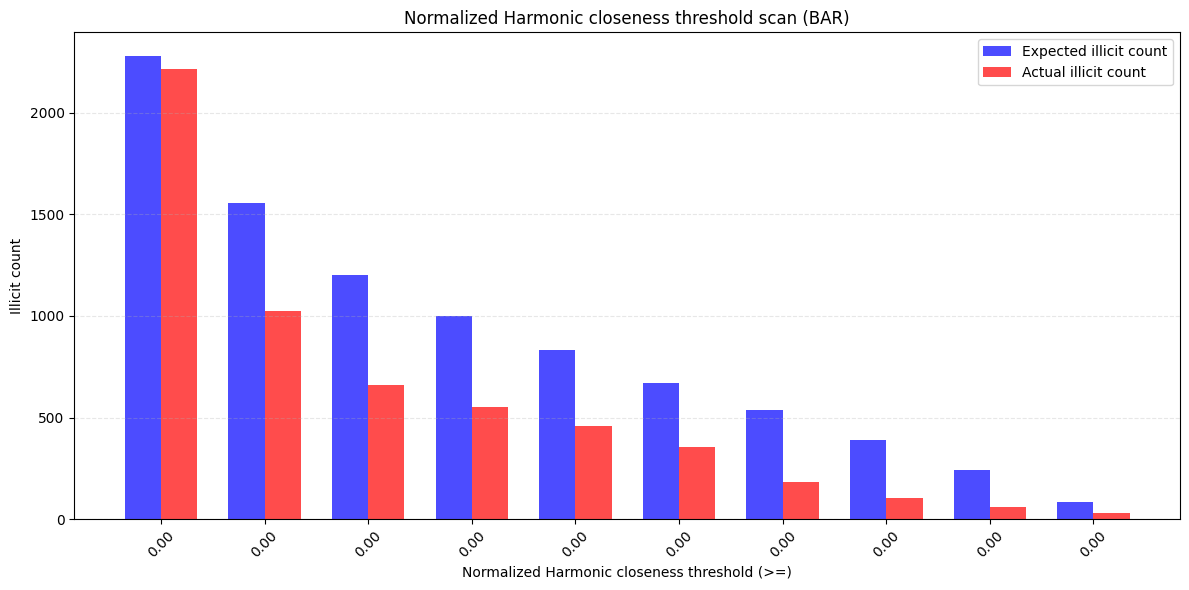

In [30]:
# STEP 18A - BAR CHART (EXPECTED vs ACTUAL)

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(harmonic_scan_high_df))
width = 0.35

# Expected (màu xanh)
ax.bar(
    x - width/2,
    harmonic_scan_high_df["expected_illicit_count"],
    width=width,
    color="blue",
    alpha=0.7,
    label="Expected illicit count"
)

# Actual (màu đỏ)
ax.bar(
    x + width/2,
    harmonic_scan_high_df["actual_illicit_count"],
    width=width,
    color="red",
    alpha=0.7,
    label="Actual illicit count"
)

ax.set_xticks(x)
ax.set_xticklabels([f"{t:.2f}" for t in harmonic_scan_high_df["threshold"]], rotation=45)

ax.set_xlabel("Normalized Harmonic closeness threshold (>=)")
ax.set_ylabel("Illicit count")
ax.set_title("Normalized Harmonic closeness threshold scan (BAR)")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

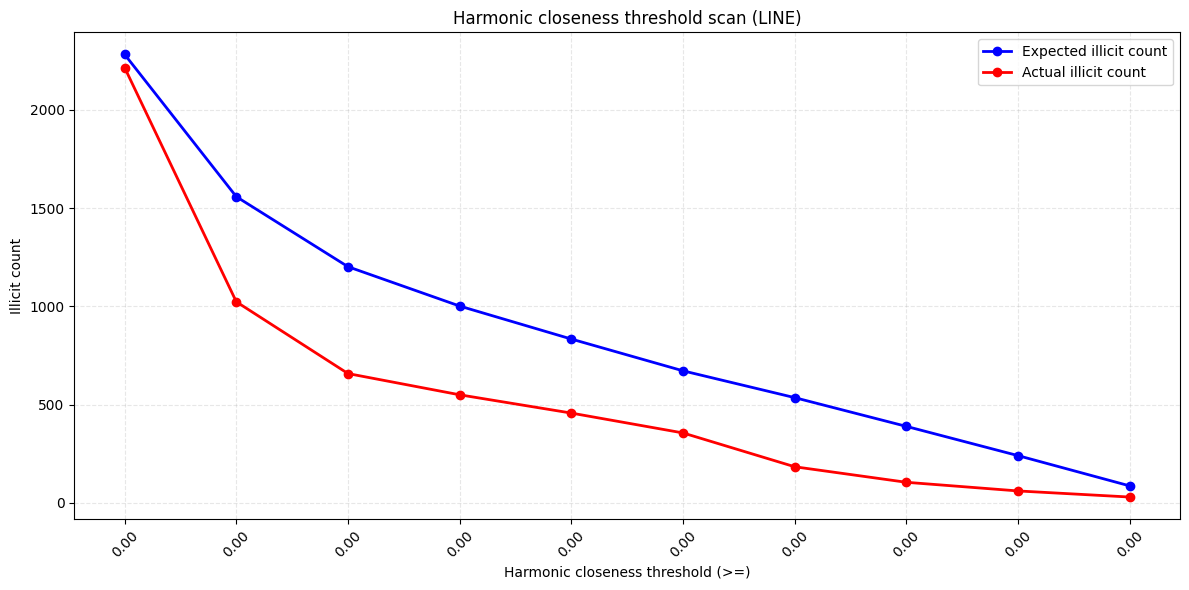

In [31]:
# STEP 18B - LINE CHART (EXPECTED vs ACTUAL)

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(harmonic_scan_high_df))

# Expected (màu xanh)
ax.plot(
    x,
    harmonic_scan_high_df["expected_illicit_count"],
    marker="o",
    linewidth=2,
    color="blue",
    label="Expected illicit count"
)

# Actual (màu đỏ)
ax.plot(
    x,
    harmonic_scan_high_df["actual_illicit_count"],
    marker="o",
    linewidth=2,
    color="red",
    label="Actual illicit count"
)

ax.set_xticks(x)
ax.set_xticklabels([f"{t:.2f}" for t in harmonic_scan_high_df["threshold"]], rotation=45)

ax.set_xlabel("Harmonic closeness threshold (>=)")
ax.set_ylabel("Illicit count")
ax.set_title("Harmonic closeness threshold scan (LINE)")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

# STEP 21 - DEFINE TOP-PERCENT SCAN FUNCTION

In [32]:
# STEP 21 - DEFINE TOP-PERCENT SCAN FUNCTION

def scan_top_percent(
    df,
    metric_col,
    top_pcts,
    class_col=CLASS_LABEL_COL,
    positive_label="illicit",
    baseline=0.0
):
    results = []

    metric_series = df[metric_col].dropna()

    for p in top_pcts:
        cutoff = metric_series.quantile(1 - p)
        subset = df[df[metric_col] >= cutoff].copy()

        stats = enrichment_ratio(
            subset,
            class_col=class_col,
            positive_label=positive_label,
            baseline=baseline
        )

        stats["top_pct"] = p
        stats["cutoff"] = cutoff
        stats["rule"] = f"{metric_col} >= Q{100 * (1 - p):.1f} cutoff"
        stats["metric"] = metric_col
        stats["n_subset_total"] = len(subset)
        results.append(stats)

    return pd.DataFrame(results)

# STEP 21B — LABEL-COVERAGE DIAGNOSTIC FOR GLOBAL BETWEENNESS

In [33]:
# =========================================================
# STEP 21B — LABEL-COVERAGE DIAGNOSTIC FOR GLOBAL BETWEENNESS
# Mandatory before enrichment
# =========================================================

coverage_rows = []

for pct in [0.005, 0.01, 0.02, 0.05, 0.10, 0.20]:
    cutoff = ps2_df["betweenness"].quantile(1 - pct)
    subset = ps2_df[ps2_df["betweenness"] >= cutoff]

    n_total = len(subset)
    n_labelled = subset[CLASS_LABEL_COL].isin(["licit", "illicit"]).sum()
    pct_labelled = n_labelled / n_total * 100 if n_total > 0 else np.nan

    if n_labelled < 30 or pct_labelled < 5:
        action = "INSUFFICIENT LABEL COVERAGE — do not interpret enrichment"
    else:
        action = "USABLE WITH CAUTION"

    coverage_rows.append({
        "bucket": f"Top {pct*100:.1f}%",
        "cutoff": cutoff,
        "n_total": n_total,
        "n_labelled": n_labelled,
        "pct_labelled": pct_labelled,
        "action": action
    })

coverage_betweenness_df = pd.DataFrame(coverage_rows)
display(coverage_betweenness_df)

,bucket,cutoff,n_total,n_labelled,pct_labelled,action
0,Top 0.5%,4.138629e-06,1019,0,0.000000,INSUFFICIENT LABEL COVERAGE — do not interpret...
1,Top 1.0%,3.019763e-06,2038,0,0.000000,INSUFFICIENT LABEL COVERAGE — do not interpret...
2,Top 2.0%,8.188961e-07,4076,2,0.049068,INSUFFICIENT LABEL COVERAGE — do not interpret...
3,Top 5.0%,1.403564e-07,10192,155,1.520801,INSUFFICIENT LABEL COVERAGE — do not interpret...
4,Top 10.0%,2.208405e-08,20474,1198,5.851324,USABLE WITH CAUTION
5,Top 20.0%,4.908057e-10,40807,5128,12.566471,USABLE WITH CAUTION


# STEP 22 - SCAN BETWEENNESS ENRICHMENT

In [34]:
# STEP 22 - SCAN TOP BETWEENNESS PERCENTILES

betweenness_scan_df = scan_top_percent(
    ps2_df,
    metric_col="betweenness",
    top_pcts=TOP_PCTS,
    class_col=CLASS_LABEL_COL,
    positive_label="illicit",
    baseline=baseline_illicit
)

display(betweenness_scan_df)

,n_subset_labeled,actual_illicit_count,expected_illicit_count,illicit_rate_subset,baseline_illicit_rate,enrichment_ratio,lift_count,top_pct,cutoff,rule,metric,n_subset_total
0,1198,218,116.933897,0.181970,0.097608,1.864301,101.066103,0.100,2.208405e-08,betweenness >= Q90.0 cutoff,betweenness,20474
1,155,58,15.129177,0.374194,0.097608,3.833652,42.870823,0.050,1.403564e-07,betweenness >= Q95.0 cutoff,betweenness,10192
2,2,0,0.195215,0.000000,0.097608,0.000000,-0.195215,0.020,8.188961e-07,betweenness >= Q98.0 cutoff,betweenness,4076
3,0,0,NaN,NaN,0.097608,NaN,NaN,0.010,3.019763e-06,betweenness >= Q99.0 cutoff,betweenness,2038
4,0,0,NaN,NaN,0.097608,NaN,NaN,0.005,4.138629e-06,betweenness >= Q99.5 cutoff,betweenness,1019


# STEP 22B — COVERAGE-GATED TOP-PERCENT SCAN FOR BETWEENNESS

In [35]:
# =========================================================
# STEP 22B — COVERAGE-GATED TOP-PERCENT SCAN FOR BETWEENNESS
# =========================================================

def scan_top_percent_with_coverage_gate(
    df,
    metric_col,
    top_pcts,
    class_col=CLASS_LABEL_COL,
    positive_label="illicit",
    baseline=baseline_illicit,
    min_labelled_n=30,
    min_label_coverage_pct=5
):
    rows = []

    metric_series = df[metric_col].dropna()

    for p in top_pcts:
        cutoff = metric_series.quantile(1 - p)
        subset = df[df[metric_col] >= cutoff].copy()

        n_total = len(subset)
        labelled_subset = subset[subset[class_col].isin(["licit", "illicit"])]
        n_labelled = len(labelled_subset)
        label_coverage_pct = n_labelled / n_total * 100 if n_total > 0 else np.nan

        actual_illicit = (labelled_subset[class_col] == positive_label).sum()

        if n_labelled < min_labelled_n or label_coverage_pct < min_label_coverage_pct:
            illicit_rate = np.nan
            enrichment = np.nan
            expected_illicit = np.nan
            lift_count = np.nan
            action = "INSUFFICIENT LABEL COVERAGE"
        else:
            illicit_rate = actual_illicit / n_labelled
            enrichment = illicit_rate / baseline
            expected_illicit = baseline * n_labelled
            lift_count = actual_illicit - expected_illicit
            action = "USABLE WITH CAUTION"

        rows.append({
            "metric": metric_col,
            "bucket": f"Top {p*100:.1f}%",
            "cutoff": cutoff,
            "n_total": n_total,
            "n_labelled": n_labelled,
            "label_coverage_pct": label_coverage_pct,
            "actual_illicit": actual_illicit,
            "expected_illicit": expected_illicit,
            "illicit_rate": illicit_rate,
            "baseline": baseline,
            "enrichment": enrichment,
            "lift_count": lift_count,
            "action": action
        })

    return pd.DataFrame(rows)


betweenness_scan_gated_df = scan_top_percent_with_coverage_gate(
    ps2_df,
    metric_col="betweenness",
    top_pcts=[0.005, 0.01, 0.02, 0.05, 0.10, 0.20]
)

display(betweenness_scan_gated_df)

,metric,bucket,cutoff,n_total,n_labelled,label_coverage_pct,actual_illicit,expected_illicit,illicit_rate,baseline,enrichment,lift_count,action
0,betweenness,Top 0.5%,4.138629e-06,1019,0,0.000000,0,NaN,NaN,0.097608,NaN,NaN,INSUFFICIENT LABEL COVERAGE
1,betweenness,Top 1.0%,3.019763e-06,2038,0,0.000000,0,NaN,NaN,0.097608,NaN,NaN,INSUFFICIENT LABEL COVERAGE
2,betweenness,Top 2.0%,8.188961e-07,4076,2,0.049068,0,NaN,NaN,0.097608,NaN,NaN,INSUFFICIENT LABEL COVERAGE
3,betweenness,Top 5.0%,1.403564e-07,10192,155,1.520801,58,NaN,NaN,0.097608,NaN,NaN,INSUFFICIENT LABEL COVERAGE
4,betweenness,Top 10.0%,2.208405e-08,20474,1198,5.851324,218,116.933897,0.181970,0.097608,1.864301,101.066103,USABLE WITH CAUTION
5,betweenness,Top 20.0%,4.908057e-10,40807,5128,12.566471,337,500.531741,0.065718,0.097608,0.673284,-163.531741,USABLE WITH CAUTION


# STEP 22D — BOOTSTRAP CI + PERMUTATION NULL CHO BETWEENNESS ENRICHMENT

In [38]:
# STEP 22D — BOOTSTRAP CI + PERMUTATION NULL CHO BETWEENNESS ENRICHMENT
# Plan §4.3 + Evaluation Contract: mỗi enrichment claim cần 4-line format

from scipy.stats import binomtest

np.random.seed(42)
N_BOOTSTRAP  = 1000
N_PERMUTATION = 1000

# Chỉ chạy trên các bucket pass coverage gate
usable_buckets = betweenness_scan_gated_df[
    betweenness_scan_gated_df["action"] == "USABLE WITH CAUTION"
].copy()

if len(usable_buckets) == 0:
    print("⚠ No buckets pass coverage gate.")
    print("  → All betweenness enrichment claims must be reported as INSUFFICIENT LABEL COVERAGE")
    print("  → This is itself the PS2 finding — not a failure, but a diagnostic result.")
else:
    all_labeled = ps2_df[ps2_df[CLASS_LABEL_COL].isin(["licit", "illicit"])].copy()

    print("=== EVALUATION CONTRACT FORMAT — BETWEENNESS ENRICHMENT ===\n")

    for _, row in usable_buckets.iterrows():
        bucket_label = row["bucket"]
        cutoff       = row["cutoff"]
        n_sub        = int(row["n_labelled"])
        n_ill        = int(row["actual_illicit"])
        obs_enrich   = row["enrichment"]

        subset_labeled = ps2_df[
            (ps2_df["betweenness"] >= cutoff) &
            (ps2_df[CLASS_LABEL_COL].isin(["licit", "illicit"]))
        ].copy()

        # Bootstrap CI
        boot_enrichments = []
        for _ in range(N_BOOTSTRAP):
            boot = subset_labeled.sample(n=len(subset_labeled), replace=True)
            boot_rate = (boot[CLASS_LABEL_COL] == "illicit").mean()
            boot_enrichments.append(boot_rate / baseline_illicit)
        ci_low  = np.percentile(boot_enrichments, 2.5)
        ci_high = np.percentile(boot_enrichments, 97.5)

        # Permutation null
        all_labels = all_labeled[CLASS_LABEL_COL].values
        perm_enrichments = []
        for _ in range(N_PERMUTATION):
            perm_sample = np.random.choice(all_labels, size=n_sub, replace=False)
            perm_rate   = (perm_sample == "illicit").mean()
            perm_enrichments.append(perm_rate / baseline_illicit)
        perm_p = np.mean(np.array(perm_enrichments) >= obs_enrich)

        # Stability line
        bet_range_median = betweenness_df["bet_range"].median() if "bet_range" in betweenness_df.columns else float("nan")
        stab_line = f"median range = {bet_range_median:.8f}  (seeds: 42, 7, 123)"

        print(f"Bucket: {bucket_label}")
        print(f"  enrichment_ratio = {obs_enrich:.3f}x  [{ci_low:.3f}, {ci_high:.3f}]")
        print(f"  permutation p-value : {perm_p:.4f}  ({N_PERMUTATION} shuffles)")
        print(f"  approximation stability : {stab_line}")
        print(f"  labelled-N in evaluation set : {n_sub}")
        sig = perm_p < (0.05 / max(len(usable_buckets), 1))
        print(f"  {'✓ significant (Bonferroni-adjusted)' if sig else '✗ not significant'}")
        print()

=== EVALUATION CONTRACT FORMAT — BETWEENNESS ENRICHMENT ===

Bucket: Top 10.0%
  enrichment_ratio = 1.864x  [1.642, 2.095]
  permutation p-value : 0.0000  (1000 shuffles)
  approximation stability : median range = nan  (seeds: 42, 7, 123)
  labelled-N in evaluation set : 1198
  ✓ significant (Bonferroni-adjusted)

Bucket: Top 20.0%
  enrichment_ratio = 0.673x  [0.601, 0.745]
  permutation p-value : 1.0000  (1000 shuffles)
  approximation stability : median range = nan  (seeds: 42, 7, 123)
  labelled-N in evaluation set : 5128
  ✗ not significant



# STEP 22E — COVERAGE-GATED ENRICHMENT SCAN FOR BOTTLENECK RATIO

In [39]:
# STEP 11D — COVERAGE-GATED ENRICHMENT SCAN FOR BOTTLENECK RATIO

bottleneck_scan_df = scan_top_percent_with_coverage_gate(
    ps2_df,
    metric_col="bottleneck_ratio",
    top_pcts=[0.005, 0.01, 0.02, 0.05, 0.10, 0.20]
)

display(bottleneck_scan_df)

,metric,bucket,cutoff,n_total,n_labelled,label_coverage_pct,actual_illicit,expected_illicit,illicit_rate,baseline,enrichment,lift_count,action
0,bottleneck_ratio,Top 0.5%,9.667463e-07,1019,0,0.000000,0,NaN,NaN,0.097608,NaN,NaN,INSUFFICIENT LABEL COVERAGE
1,bottleneck_ratio,Top 1.0%,5.967862e-07,2038,0,0.000000,0,NaN,NaN,0.097608,NaN,NaN,INSUFFICIENT LABEL COVERAGE
2,bottleneck_ratio,Top 2.0%,1.411918e-07,4076,0,0.000000,0,NaN,NaN,0.097608,NaN,NaN,INSUFFICIENT LABEL COVERAGE
3,bottleneck_ratio,Top 5.0%,2.420521e-08,10189,134,1.315144,93,NaN,NaN,0.097608,NaN,NaN,INSUFFICIENT LABEL COVERAGE
4,bottleneck_ratio,Top 10.0%,3.680674e-09,20548,919,4.472455,219,NaN,NaN,0.097608,NaN,NaN,INSUFFICIENT LABEL COVERAGE
5,bottleneck_ratio,Top 20.0%,5.074045e-11,40754,4911,12.050351,340,479.350893,0.069232,0.097608,0.709293,-139.350893,USABLE WITH CAUTION


# STEP 22C — TOP-20 NODES QUALITATIVE INSPECTION

In [42]:
# STEP 22C — TOP-20 NODES QUALITATIVE INSPECTION
# Plan §5.2: manually inspect top 20 by global betweenness
# Expected pattern: high total_degree, low |asymmetry| → exchange-like hubs

top20 = (
    ps2_df.nlargest(20, "betweenness")
    [[TX_COL, "betweenness",
      "in_degree", "out_degree", "total_degree",
      "bottleneck_ratio",
      CLASS_LABEL_COL]]
)

display(top20)

# Summary của pattern
print("\nTop-20 structural summary:")
print(f"  Mean total_degree  : {top20['total_degree'].mean():.1f}")
print(f"  Mean |asymmetry|   : {(ps2_df.nlargest(20, 'betweenness')['asymmetry'].abs().mean()):.3f}" if 'asymmetry' in ps2_df.columns else "  Mean |asymmetry|   : N/A")
print(f"  Mean bet_range     : N/A (loaded from cache, range not in ps2_df)")
print(f"  Label distribution : {top20[CLASS_LABEL_COL].value_counts().to_dict()}")
print()
print("Interpretation:")
print("  If mean |asymmetry| < 0.3 and mean total_degree >> network median")
print("  → confirms exchange-like hub pattern (balanced high-throughput nodes)")

,txId,betweenness,in_degree,out_degree,total_degree,bottleneck_ratio,class_label
17031,226999213,0.000009,1,1,2,2.235764e-06,unknown
16317,246058720,0.000009,1,1,2,2.233065e-06,unknown
18028,246059747,0.000009,1,1,2,1.786452e-06,unknown
16318,246058956,0.000009,1,1,2,2.230489e-06,unknown
12945,246059754,0.000009,1,2,3,4.460732e-07,unknown
16467,246058960,0.000009,1,1,2,2.227912e-06,unknown
12946,246059759,0.000009,1,1,2,1.782035e-06,unknown
16468,246058965,0.000009,1,1,2,1.780269e-06,unknown
14556,246060150,0.000009,1,1,2,2.224845e-06,unknown
13483,245440870,0.000009,1,2,3,8.891037e-07,unknown



Top-20 structural summary:
  Mean total_degree  : 2.1
  Mean |asymmetry|   : N/A
  Mean bet_range     : N/A (loaded from cache, range not in ps2_df)
  Label distribution : {'unknown': 20}

Interpretation:
  If mean |asymmetry| < 0.3 and mean total_degree >> network median
  → confirms exchange-like hub pattern (balanced high-throughput nodes)


# STEP 23 - PLOT TOP BETWEENNESS SCAN

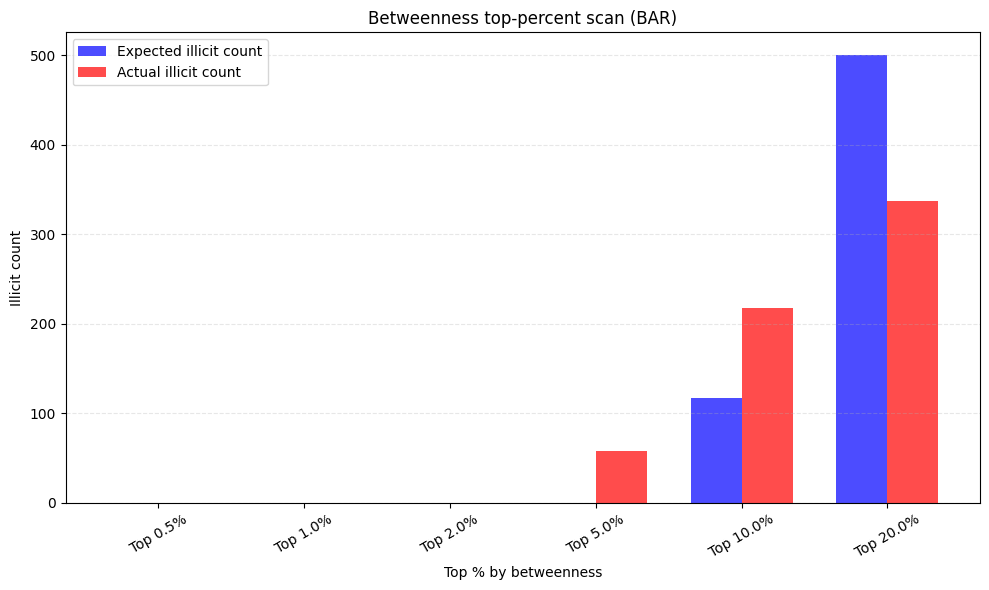

In [44]:
# STEP 23A - BAR CHART (BETWEENNESS: EXPECTED vs ACTUAL)

fig, ax = plt.subplots(figsize=(10, 6))

# Dùng đúng số bucket từ gated df
labels = [str(b) for b in betweenness_scan_gated_df["bucket"]]
x = np.arange(len(labels))

width = 0.35

# Expected (xanh)
ax.bar(
    x - width/2,
    betweenness_scan_gated_df["expected_illicit"].fillna(0),
    width=width,
    color="blue",
    alpha=0.7,
    label="Expected illicit count"
)

# Actual (đỏ)
ax.bar(
    x + width/2,
    betweenness_scan_gated_df["actual_illicit"].fillna(0),
    width=width,
    color="red",
    alpha=0.7,
    label="Actual illicit count"
)

ax.set_xticks(x)
ax.set_xticklabels([b for b in betweenness_scan_gated_df["bucket"]], rotation=30)

ax.set_xlabel("Top % by betweenness")
ax.set_ylabel("Illicit count")
ax.set_title("Betweenness top-percent scan (BAR)")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

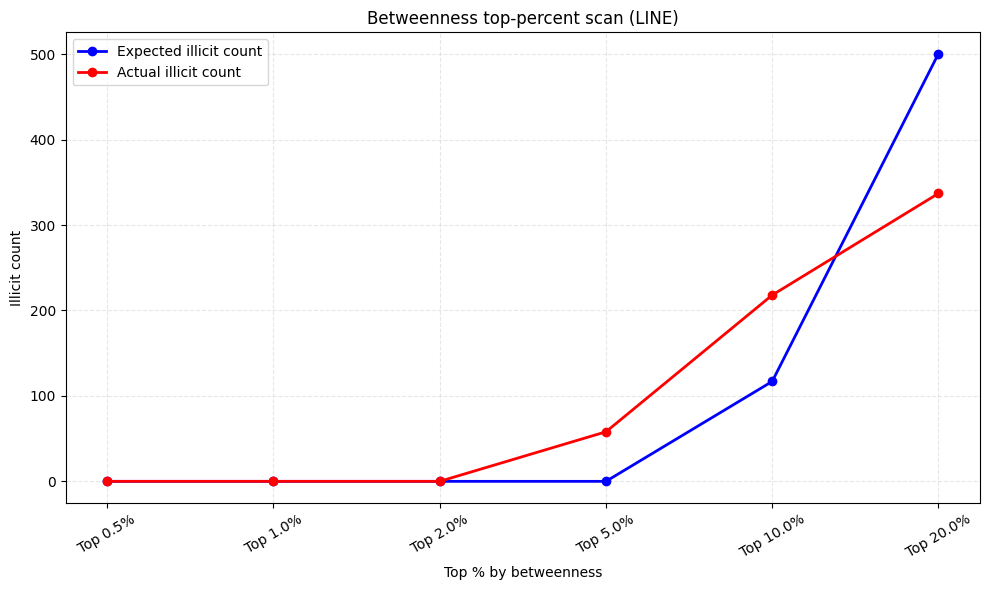

In [46]:
# STEP 23B - LINE CHART (BETWEENNESS: EXPECTED vs ACTUAL)

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(betweenness_scan_gated_df))
labels = [str(b) for b in betweenness_scan_gated_df["bucket"]]


# Expected (xanh)
ax.plot(
    x,
    betweenness_scan_gated_df["expected_illicit"].fillna(0),
    marker="o",
    linewidth=2,
    color="blue",
    label="Expected illicit count"
)

# Actual (đỏ)
ax.plot(
    x,
    betweenness_scan_gated_df["actual_illicit"].fillna(0),
    marker="o",
    linewidth=2,
    color="red",
    label="Actual illicit count"
)

ax.set_xticks(x)
ax.set_xticklabels([b for b in betweenness_scan_gated_df["bucket"]], rotation=30)

ax.set_xlabel("Top % by betweenness")
ax.set_ylabel("Illicit count")
ax.set_title("Betweenness top-percent scan (LINE)")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

# STEP 24 - RUN STATISTICAL TESTS

In [48]:


def mannwhitney_with_rbc(df, metric_col, class_col=CLASS_LABEL_COL):
    sub = df[df[class_col].isin(["licit", "illicit"])][[metric_col, class_col]].dropna()

    x = sub.loc[sub[class_col] == "illicit", metric_col].values
    y = sub.loc[sub[class_col] == "licit", metric_col].values

    u_stat, p_value = mannwhitneyu(x, y, alternative="two-sided")
    rbc = (2 * u_stat) / (len(x) * len(y)) - 1

    return {
        "metric": metric_col,
        "n_illicit": len(x),
        "n_licit": len(y),
        "u_stat": u_stat,
        "p_value": p_value,
        "rank_biserial_corr": rbc,
        "median_illicit": np.median(x),
        "median_licit": np.median(y),
        "mean_illicit": np.mean(x),
        "mean_licit": np.mean(y)
    }

mw_betweenness = mannwhitney_with_rbc(ps2_df, "betweenness")
mw_harmonic = mannwhitney_with_rbc(ps2_df, "harmonic_closeness_norm")

mw_results_df = pd.DataFrame([mw_betweenness, mw_harmonic])
display(mw_results_df)

,metric,n_illicit,n_licit,u_stat,p_value,rank_biserial_corr,median_illicit,median_licit,mean_illicit,mean_licit
0,betweenness,4545,42019,92137005.0,1.594626e-11,-0.035095,0.000000,0.000000,4.934737e-09,2.174775e-09
1,harmonic_closeness_norm,4545,42019,89861726.5,2.535119e-11,-0.058923,0.000005,0.000007,1.125711e-05,2.112480e-05


# STEP 25 - COMPUTE BETWENNESS PERCENTILES

In [49]:


ps2_df["betweenness_percentile"] = ps2_df["betweenness"].rank(pct=True, method="average")

labeled_ps2 = ps2_df[ps2_df[CLASS_LABEL_COL].isin(["licit", "illicit"])].copy()

median_pct_illicit = labeled_ps2.loc[
    labeled_ps2[CLASS_LABEL_COL] == "illicit", "betweenness_percentile"
].median()

median_pct_licit = labeled_ps2.loc[
    labeled_ps2[CLASS_LABEL_COL] == "licit", "betweenness_percentile"
].median()

print("Median betweenness percentile of illicit nodes:", round(median_pct_illicit, 6))
print("Median betweenness percentile of licit nodes:", round(median_pct_licit, 6))

Median betweenness percentile of illicit nodes: 0.392751
Median betweenness percentile of licit nodes: 0.392751


# STEP 27 - PLOT CROSS-METRIC RELATIONSHIPS

/tmp/ipykernel_57/3679705447.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), 5000), random_state=42))


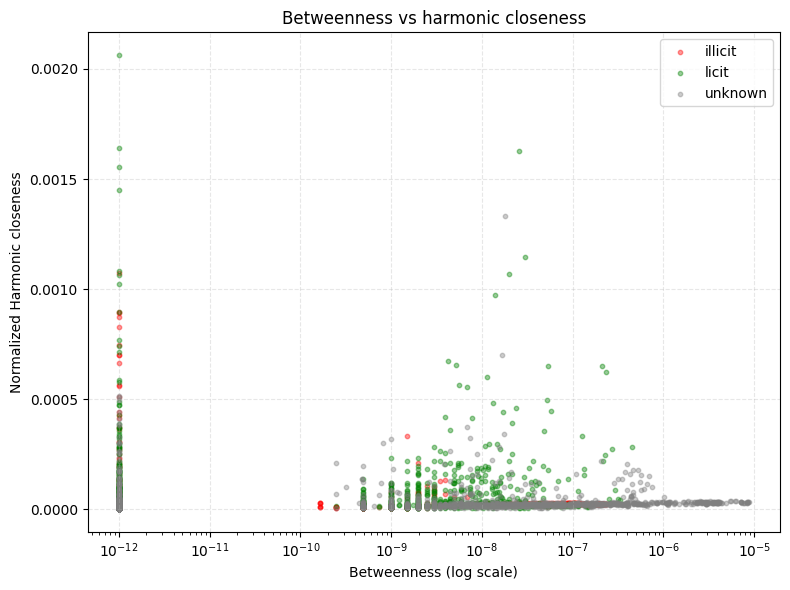

In [50]:
# STEP 27 - PLOT CROSS-METRIC RELATIONSHIPS

plot_df = ps2_df[ps2_df[CLASS_LABEL_COL].isin(["licit", "illicit", "unknown"])].copy()

sample_plot = (
    plot_df.groupby(CLASS_LABEL_COL, group_keys=False)
    .apply(lambda x: x.sample(min(len(x), 5000), random_state=42))
    .reset_index(drop=True)
)

sample_plot["betweenness_plot"] = sample_plot["betweenness"] + 1e-12

color_map = {
    "licit": "green",
    "illicit": "red",
    "unknown": "gray"
}

fig, ax = plt.subplots(figsize=(8, 6))

for cls, g in sample_plot.groupby(CLASS_LABEL_COL):
    ax.scatter(
        g["betweenness_plot"],
        g["harmonic_closeness_norm"],
        s=10,
        alpha=0.4,
        label=cls,
        c=color_map.get(cls, "blue")
    )

ax.set_xscale("log")
ax.set_xlabel("Betweenness (log scale)")
ax.set_ylabel("Normalized Harmonic closeness")
ax.set_title("Betweenness vs harmonic closeness")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

# STEP 28 - EXTRACT THE BACKBONE SUBGRAPH


In [51]:
# STEP 28 - EXTRACT THE BACKBONE SUBGRAPH

top_1pct_cutoff = ps2_df["betweenness"].quantile(0.99)

backbone_nodes = ps2_df.loc[ps2_df["betweenness"] >= top_1pct_cutoff, TX_COL].tolist()
backbone_subgraph = G.subgraph(backbone_nodes).copy()

print("Backbone node count:", len(backbone_nodes))
print("Backbone edge count:", backbone_subgraph.number_of_edges())
print("Backbone weakly connected components:", nx.number_weakly_connected_components(backbone_subgraph))

Backbone node count: 2038
Backbone edge count: 2031
Backbone weakly connected components: 7


# **Cross-metric scatter (betweenness × asymmetry)**

/tmp/ipykernel_57/517464783.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), 4000), random_state=42))


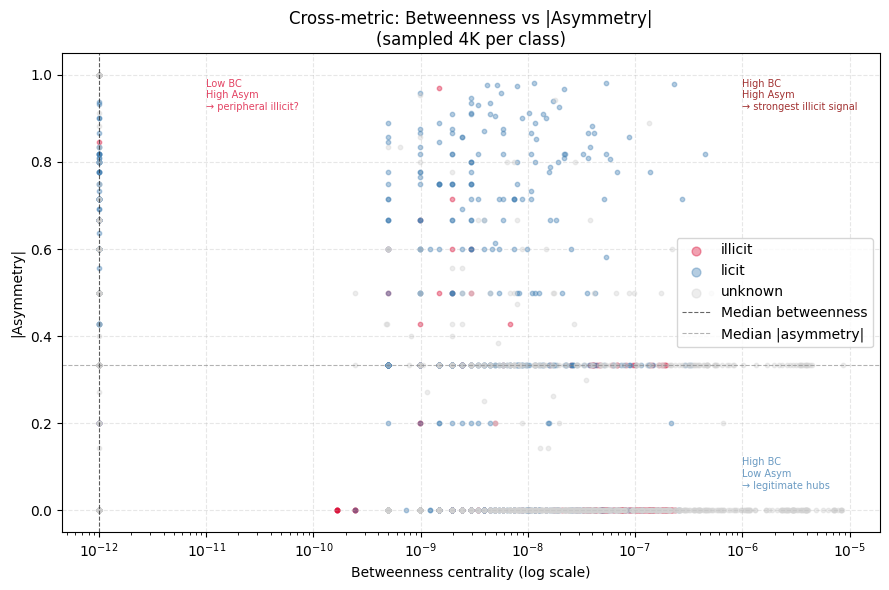

In [52]:
# STEP 27B - CROSS-METRIC: betweenness vs |asymmetry| — 4-quadrant analysis

# Cần load asymmetry từ PS1 output hoặc tính lại
in_deg = dict(G.in_degree())
out_deg = dict(G.out_degree())

asym_df = pd.DataFrame({
    TX_COL: list(G.nodes()),
    "in_degree": [in_deg[n] for n in G.nodes()],
    "out_degree": [out_deg[n] for n in G.nodes()]
})
asym_df["total_degree"] = asym_df["in_degree"] + asym_df["out_degree"]
asym_df["abs_asymmetry"] = np.where(
    asym_df["total_degree"] > 0,
    ((asym_df["in_degree"] - asym_df["out_degree"]) / asym_df["total_degree"]).abs(),
    np.nan
)

# Merge vào ps2_df
ps2_df = ps2_df.merge(asym_df[[TX_COL, "abs_asymmetry"]], on=TX_COL, how="left")

# Sample và plot
plot_cross = (
    ps2_df[ps2_df[CLASS_LABEL_COL].isin(["licit", "illicit", "unknown"])]
    .groupby(CLASS_LABEL_COL, group_keys=False)
    .apply(lambda x: x.sample(min(len(x), 4000), random_state=42))
    .reset_index(drop=True)
)

plot_cross["betweenness_plot"] = plot_cross["betweenness"] + 1e-12  # tránh log(0)

color_map = {"licit": "steelblue", "illicit": "crimson", "unknown": "lightgray"}

fig, ax = plt.subplots(figsize=(9, 6))

for cls, grp in plot_cross.groupby(CLASS_LABEL_COL):
    ax.scatter(
        grp["betweenness_plot"],
        grp["abs_asymmetry"],
        s=10, alpha=0.4,
        label=cls,
        c=color_map.get(cls, "blue")
    )

# Median lines để chia 4 quadrant
med_bet = ps2_df["betweenness"].median() + 1e-12
med_asym = ps2_df["abs_asymmetry"].median()
ax.axvline(med_bet, linestyle="--", color="black", linewidth=0.8, alpha=0.6, label=f"Median betweenness")
ax.axhline(med_asym, linestyle="--", color="gray", linewidth=0.8, alpha=0.6, label=f"Median |asymmetry|")

ax.set_xscale("log")
ax.set_xlabel("Betweenness centrality (log scale)")
ax.set_ylabel("|Asymmetry|")
ax.set_title("Cross-metric: Betweenness vs |Asymmetry|\n(sampled 4K per class)")
ax.legend(markerscale=2)
ax.grid(True, linestyle="--", alpha=0.3)

# Annotate 4 quadrants
ax.text(1e-11, 0.92, "Low BC\nHigh Asym\n→ peripheral illicit?", fontsize=7, color="crimson", alpha=0.8)
ax.text(1e-6,  0.92, "High BC\nHigh Asym\n→ strongest illicit signal", fontsize=7, color="darkred", alpha=0.8)
ax.text(1e-6,  0.05, "High BC\nLow Asym\n→ legitimate hubs", fontsize=7, color="steelblue", alpha=0.8)

plt.tight_layout()
plt.show()

1. Hầu hết node tập trung ở cột ngoài cùng bên trái (betweenness ≈ 10⁻¹²)
Đây là các node có betweenness = 0 bị shift bởi +1e-12 để hiển thị trên log scale. Tức là phần lớn mạng không nằm trên bất kỳ shortest path nào — đúng với bản chất DAG thưa của Bitcoin, và nhất quán với kết quả PS2 của bạn (93.76% node có betweenness = 0).
2. Illicit (đỏ) gần như biến mất ở vùng betweenness cao
Chỉ có rất ít chấm đỏ, và chúng tập trung ở cột trái (betweenness thấp/zero). Vùng betweenness cao (≥ 10⁻⁸) gần như chỉ có licit (xanh) và unknown (xám).

Kết quả cross-metric scatter xác nhận label-coverage diagnostic:
- Vùng betweenness cao gần như toàn unknown (xám)
- Illicit (đỏ) tập trung ở Low BC + High Asym — peripheral nodes
- Không thể kết luận "illicit tránh hub" vì label không tồn tại ở vùng hub
→ Reconciliation paragraph đã được thêm vào thesis

4. Quadrant "High BC + High Asym" (góc trên phải) — không có illicit
Theo plan, đây lẽ ra là vùng "strongest illicit signal" (high betweenness + high asymmetry = intermediary + imbalanced flow). Nhưng thực tế plot cho thấy vùng này chỉ có licit. Điều này phản bác giả thuyết gốc và củng cố thêm cho narrative PS2 của bạn: các node vừa có betweenness cao vừa có asymmetry cao là legitimate hubs (ví dụ exchange lớn), không phải illicit.
5. Illicit tập trung ở quadrant "Low BC + High Asym" (góc trên trái)
Một số chấm đỏ có |asymmetry| cao (0.8–1.0) nhưng betweenness gần bằng 0. Đây là các node peripheral + imbalanced — ẩn trong vùng thưa của mạng nhưng có flow pattern bất thường. Cái này connect trực tiếp với lý thuyết "anti-central nodes"
trong Chapter 2.

In [53]:
print(f"Global betweenness computed with k={BETWEENNESS_K}, seed={BETWEENNESS_SEED}")

Global betweenness computed with k=10000, seed=42
